In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import seaborn as sns
from typing import Literal
from config.constants import Paths
from utils.plotting import *
from results_analysis import DataExtractor

In [3]:
# Definition of rename dictionaries for better visualization in plots

rename_fs_method = {
    "CSFS feature_importance": "CSFS\n(FI)",
    "CSFS correlation": "CSFS\n(corr.)",
    "CSFS random": "CSFS\n(rnd.)",
    "CSFS singletons": "SFS",
    "mutual_info": "MI",
    "f_value": "F-value",
    "RF_FI": "RF FI",
}


def requires_clustering(
    fs_method: Literal["CSFS", "mutual_info", "f_value", "RF_FI"],
):
    return fs_method == "CSFS"

In [4]:
# Helpers for LaTeX formatting of results
def median_and_ci_to_latex(arr: np.ndarray, p: float, precision: int = 2) -> str:
        x = (1 - p) * 100 / 2
        ci = p * 100
        median = np.median(arr)
        ci_low, ci_high = np.percentile(arr, [x, 100 - x])
        # res = "${:.{precision}f}\\% ({:.0f}\\% CI: {:.{precision}f}\\% -- {:.{precision}f}\\%)$".format(median, ci, ci_low,ci_high, precision=precision)
        res = "${:.{p}f}\\%\\, (\\text{{{:.0f}\\% CI}}: {:.{p}f}\\!-\\!{:.{p}f}\\%)$".format(
            median, ci, ci_low, ci_high, p=precision
        )
        return res

def value_and_error_to_latex(
    mean: float, std: float, precision: int = 2, colorcoding: bool = False
) -> str:
    res = "${:.{precision}f} \\pm {:.{precision}f}$".format(
        mean, std, precision=precision
    )
    if colorcoding:
        if (mean - std - (0.6 / 10**precision)) > 0:
            color = "darkred"
        else:
            color = "darkgreen"
        res = res.replace("$", f"$\\textcolor{{{color}}}{{", 1)
        res = res[:-1] + "}$"
    return res

In [5]:
# Extracting results from the logger and creating a DataFrame for analysis
de = DataExtractor("paper_grid.yaml", debug=False)
all_results_df = de.get_dataframe(
    columns=[
        "name",
        "dataset.domain",
        "dataset.type",
        "feature_selection.n_features",
        "feature_selection.method",
        "model.name",
        "feature_selection.clustering.method",
        "feature_selection.direction",
        "mae",
        "rmse",
        "r2",
        "mdae",
        "me",
        "mde",
        "fs_runtime",
        "fitted_models",
        "selected_features",
        "feature_level_entries",
        "fallbacks",
        "feature_level_total_evaluated",
        "explanation",
        "fast_stops",
        "total_iterations",
    ],
    aggregation_method="none",
)

# Adding column fs_method_plot for better readability of the FS method in plots
all_results_df.loc[:, "fs_method_plot"] = all_results_df.loc[
    :, "feature_selection.method"
]
_requires_clustering_mask = all_results_df["feature_selection.method"].apply(
    requires_clustering
)

all_results_df.loc[_requires_clustering_mask, "fs_method_plot"] += (
    " "
    + all_results_df.loc[
        _requires_clustering_mask, "feature_selection.clustering.method"
    ]
)
all_results_df.loc[:, "fs_method_plot"] = all_results_df.loc[
    :, "fs_method_plot"
].replace(rename_fs_method)

# Adding column ds_plot for better readability of the dataset scenario in plots
for (domain, ds_type), ds_scenario in zip(
    [
        ("wind", "digital_twin"),
        ("wind", "forecast_available"),
        ("pv", "digital_twin"),
        ("pv", "forecast_available"),
    ],
    ["WT-S1", "WT-S2", "PV-S1", "PV-S2"],
):
    all_results_df.loc[
        (all_results_df["dataset.domain"] == domain)
        & (all_results_df["dataset.type"] == ds_type),
        "ds_plot",
    ] = ds_scenario

all_results_df.to_pickle(Paths.REPORT / "all_results_df.pkl")

  0%|          | 0/420 [00:00<?, ?it/s]

# 1. Overall Aggregation of FS Technique Performance

/tmp/ipykernel_429/2761638746.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_429/2761638746.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row_idx, col_idx].set_xticklabels(_xtick_labels)
/tmp/ipykernel_429/2761638746.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


/tmp/ipykernel_429/2761638746.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row_idx, col_idx].set_xticklabels(_xtick_labels)
/tmp/ipykernel_429/2761638746.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_429/2761638746.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row_idx, col_idx].set_xticklabels(_xtick_labels)


/tmp/ipykernel_429/2761638746.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_429/2761638746.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row_idx, col_idx].set_xticklabels(_xtick_labels)


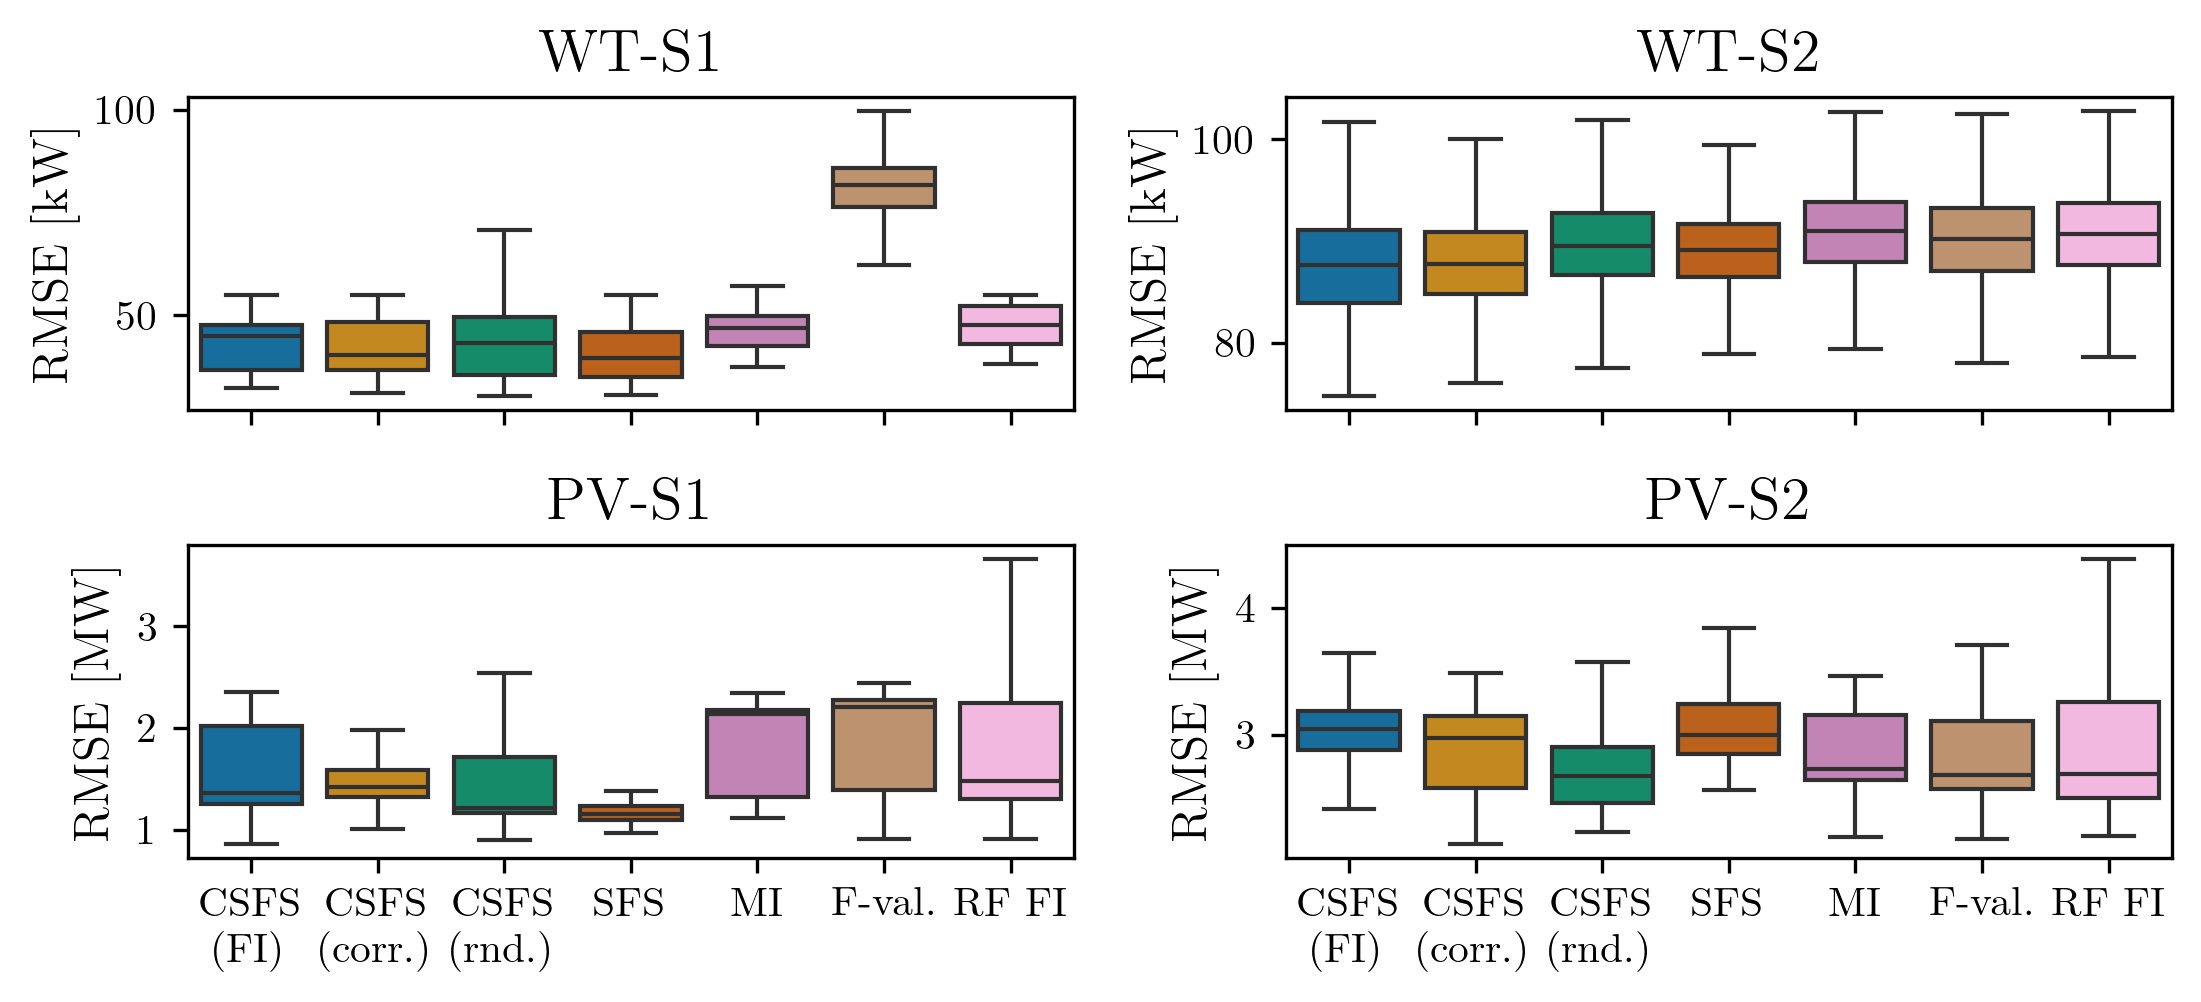

In [6]:
with plt.style.context("src/mplstyles/lncs.mplstyle"):
    titles = [["WT-S1", "WT-S2"], ["PV-S1", "PV-S2"]]
    metric = "rmse"
    fig, axs = plt.subplots(2, 2, sharex=True, sharey=False, figsize=(7.5, 3.5))
    curr_results = all_results_df.explode(metric)
    for row_idx, domain in enumerate(["wind", "pv"]):
        for col_idx, ds_type in enumerate(["digital_twin", "forecast_available"]):

            plot_df = curr_results.loc[
                (curr_results["dataset.domain"] == domain)
                & (curr_results["dataset.type"] == ds_type)
                & (curr_results["feature_selection.direction"].isin(["backward", None]))
            ]

            sns.boxplot(
                plot_df,
                x="fs_method_plot",
                y=metric,
                order=rename_fs_method.values(),
                ax=axs[row_idx, col_idx],
                palette="colorblind",
                legend=False,
                showfliers=False,
                # widths=1.5,
            )

            axs[row_idx, col_idx].set_title(titles[row_idx][col_idx])
            y_label = metric.upper() + (" [MW]" if domain == "pv" else " [kW]")
            axs[row_idx, col_idx].set_ylabel(y_label)
            axs[row_idx, col_idx].set_xlabel("")

            # Abbreviate F-value to F-val.
            _xtick_labels = [
                "F-val." if label == "F-value" else label
                for label in rename_fs_method.values()
            ]
            axs[row_idx, col_idx].set_xticklabels(_xtick_labels)

    plt.tight_layout()
    plt.show()

# 2. Predictive Model Level Performance

In [7]:
all_results_df.loc[:, ["rmse", "model.name", "dataset.domain", "dataset.type"]].explode("rmse").groupby(
    ["dataset.domain", "dataset.type", "model.name"]
).median()

rmse
dataset.domain dataset.type       model.name           
pv             digital_twin       lgbm         1.402385
                                  mlp          1.273728
                                  xgboost      1.447733
               forecast_available lgbm         2.924247
                                  mlp           2.94361
                                  xgboost      2.748439
wind           digital_twin       lgbm         49.26954
                                  mlp         41.489998
                                  xgboost     47.051248
               forecast_available lgbm        88.216997
                                  mlp         90.367532
                                  xgboost      89.38393

# 3. Performance Across Different Target Feature Set Sizes

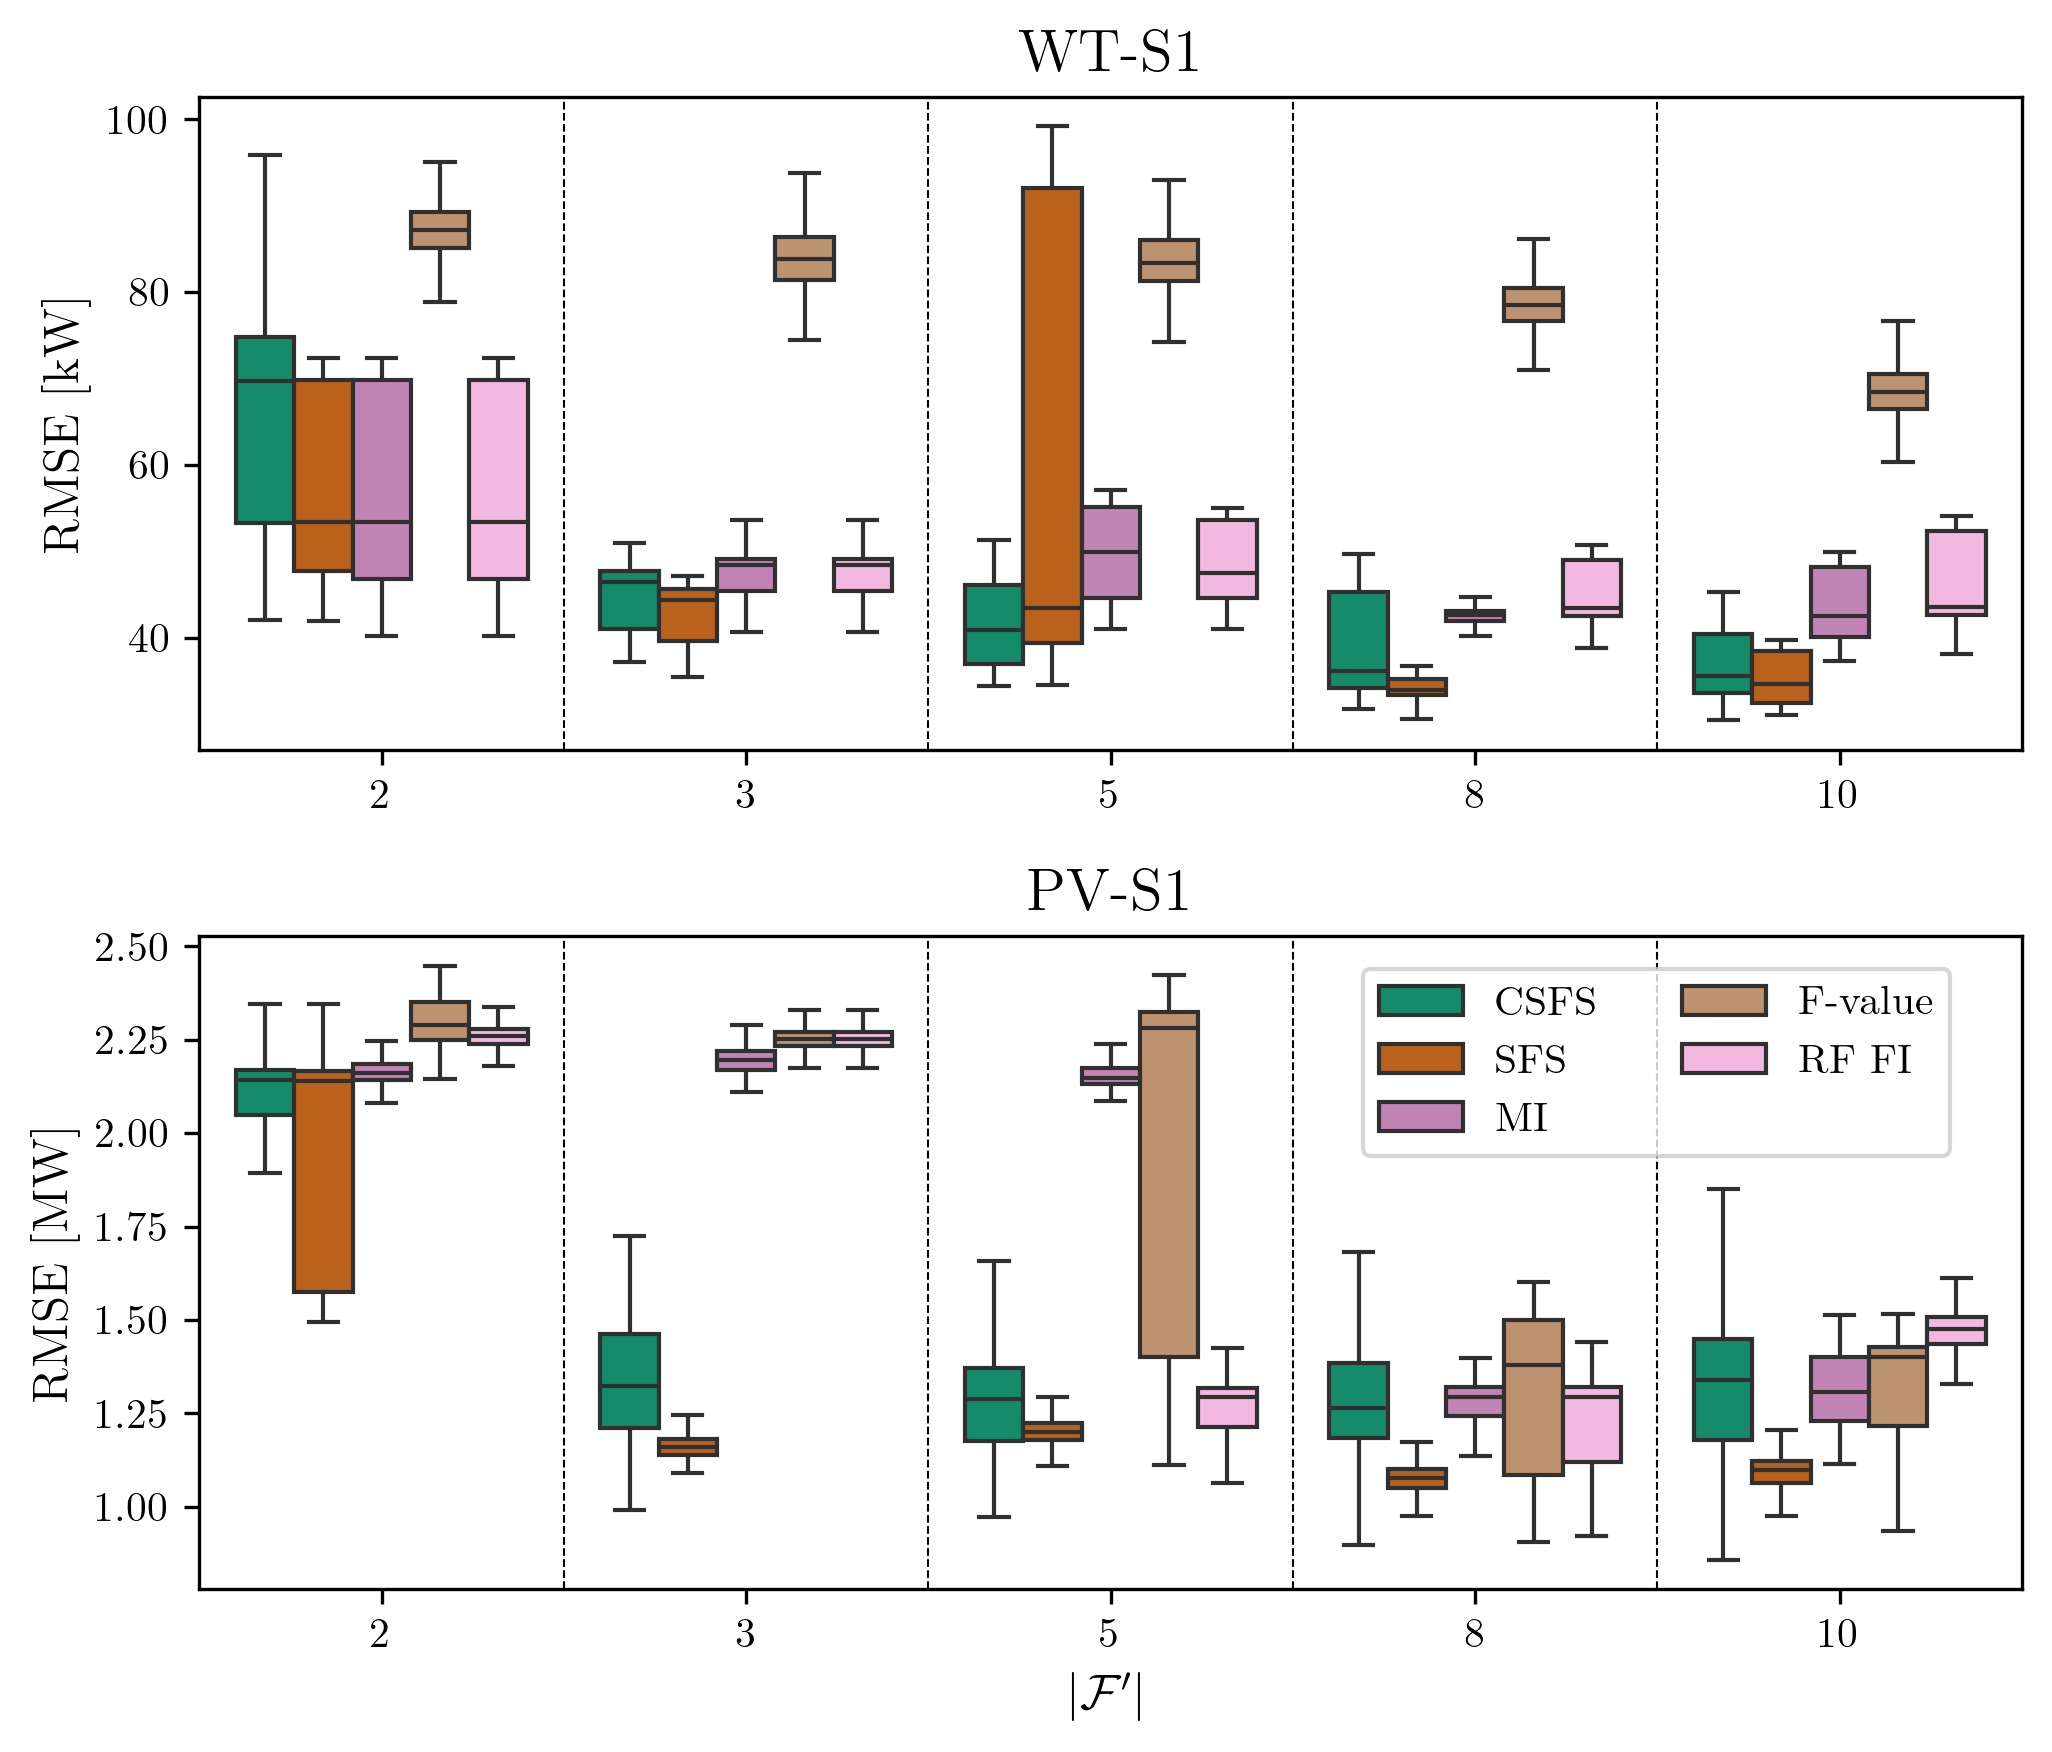

In [8]:
metric = "rmse"
fs_method_groups = {
    "CSFS": ["CSFS\n(FI)", "CSFS\n(corr.)", "CSFS\n(rnd.)"],
    "SFS": ["SFS"],
    "MI": ["MI"],
    "F-value": ["F-value"],
    "RF FI": ["RF FI"],
}
_dfs = {}
with plt.style.context("src/mplstyles/lncs.mplstyle"):
    fig, axs = plt.subplots(nrows=2, figsize=(7, 6))
    for i, ds_plot in enumerate(["WT-S1", "PV-S1"]):
        ax = axs[i]
        curr_results = all_results_df.query(f"(`ds_plot` == '{ds_plot}')").explode(
            metric
        )
        for k, v in fs_method_groups.items():
            curr_results.loc[
                curr_results["fs_method_plot"].isin(v), "fs_method_plot"
            ] = k
        _dfs[ds_plot] = curr_results
        sns.boxplot(
            curr_results,
            x="feature_selection.n_features",
            y="rmse",
            hue="fs_method_plot",
            hue_order=fs_method_groups.keys(),
            palette=sns.color_palette("colorblind", n_colors=len(fs_method_groups)+2)[2:],
            ax=ax,
            showfliers=False,
        )
        ax.set_ylabel("RMSE " + ("[MW]" if ds_plot.startswith("PV") else "[kW]"))
        ax.set_xlabel(r"$|\mathcal{F}^{\prime}|$")
        ax.set_title(ds_plot)

        [
            ax.axvline(x, color="black", linestyle="--", linewidth=0.5)
            for x in [
                0.5 + _x
                for _x in range(
                    curr_results["feature_selection.n_features"].nunique() - 1
                )
            ]
        ]

        if i == 0:
            fig.legend(ncols=2, bbox_to_anchor=(0.95, 0.46))
            ax.set_xlabel("")
        ax.get_legend().remove()

    plt.tight_layout()
    plt.savefig(
        Paths.REPORT / "all_models_rmse_over_n.pdf",
        bbox_inches="tight",
        pad_inches=0.05
    )
    plt.show()


# 4. Feature Selection Agreement

Let's analyze the Jaccard similarity of different FS techniques:

In [9]:
def jaccard(set1: list[str] | set[str], set2: list[str] | set[str]) -> float:
    if isinstance(set1, list):
        set1 = set(set1)
    result = len(set1.intersection(set2)) / len(set1.union(set2))
    # print(result)
    return result

In [10]:
import ast
import itertools
import numpy as np

try:
    jaccard  # noqa: F821
except NameError:

    def jaccard(a, b):
        a_set = set(a)
        b_set = set(b)
        if not a_set and not b_set:
            return 1.0
        if not (a_set or b_set):
            return 1.0
        inter = len(a_set & b_set)
        union = len(a_set | b_set)
        return inter / union if union > 0 else 0.0


def _ensure_iterable(x):
    """Convert a cell to a python set/list. Accepts already-iterable objects or string reprs."""
    if pd.isna(x).any():
        return set()
    if isinstance(x, (list, tuple, set)):
        return set(x)
    if isinstance(x, str):
        x_str = x.strip()
        # try to parse a python literal list / set representation
        try:
            parsed = ast.literal_eval(x_str)
            if isinstance(parsed, (list, tuple, set)):
                return set(parsed)
        except Exception:
            # fallback: split on commas (for 'f1,f2' style)
            if "," in x_str:
                return set(
                    [token.strip() for token in x_str.split(",") if token.strip() != ""]
                )
            # single feature name in string
            return {x_str}
    # fallback - try converting
    try:
        return set(list(x))
    except Exception:
        return {str(x)}


def compute_fs_agreement(
    df,
    selected_col="selected",
    fs_method_col="fs_method",
    groupby_cols=("n_features", "domain", "model", "features"),
    agg="mean",
    methods=None,
    jaccard_func=None,
):
    """
    Compute an NxN agreement matrix between feature-selection methods.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns groupby_cols + 'fs_method' + selected_col.
    selected_col : str
        Column name holding the selected feature lists/sets (or string representations).
    groupby_cols : tuple
        The columns that must be identical for a valid comparison (default as requested).
    agg : {'mean','median','min','max'} or callable
        Aggregation used across groups for each pairwise comparison.
    methods : list or None
        If provided, the order of methods to use in matrix (otherwise inferred from df).
    jaccard_func : callable or None
        Function taking two iterables and returning Jaccard index. Defaults to `jaccard` in scope.

    Returns
    -------
    pd.DataFrame
        Symmetric DataFrame index/columns = FS methods, values = aggregated agreement.
    """

    if jaccard_func is None:
        # use jaccard from outer scope or fallback
        jaccard_func = globals().get("jaccard", jaccard)

    # prepare aggregator
    if isinstance(agg, str):
        agg = agg.lower()
        if agg == "mean":
            agg_func = np.nanmean
        elif agg == "median":
            agg_func = np.nanmedian
        elif agg == "min":
            agg_func = np.nanmin
        elif agg == "max":
            agg_func = np.nanmax
        else:
            raise ValueError(
                "agg must be one of 'mean','median','min','max' or a callable"
            )
    elif callable(agg):
        agg_func = agg
    else:
        raise ValueError("agg must be a string or callable")

    # ensure required columns exist
    required = set(groupby_cols) | {fs_method_col, selected_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    # ensure selected_col is normalized to sets
    df = df.copy()
    df["_selected_set"] = df[selected_col].apply(list)

    # infer methods if not given
    methods_list = (
        list(df[fs_method_col].unique()) if methods is None else list(methods)
    )

    # dict to collect scores for each unordered pair (i,j) with i <= j
    pair_scores = defaultdict(list)

    # iterate over groups
    grouped = df.groupby(list(groupby_cols))
    for _, group in grouped:
        # map fs_method -> selected set for this group
        # If a method appears multiple times in group, we take the first occurrence (assumption).
        method_to_sel = {}
        for _, row in group.iterrows():
            m = row[fs_method_col]
            if m not in method_to_sel:
                method_to_sel[m] = row["_selected_set"]
        print(method_to_sel)

        # compute pairwise comparisons for all method pairs present in this group
        present_methods = sorted(method_to_sel.keys())
        for i, j in itertools.combinations(present_methods, 2):
            s_i = method_to_sel[i]
            s_j = method_to_sel[j]
            score = float(jaccard_func(s_i, s_j))
            pair_scores[(i, j)].append(score)

        # we may want to account for self-comparisons (diagonal) - handled below
    # print(pair_scores)
    # build result DataFrame
    methods_all = methods_list
    result = pd.DataFrame(index=methods_all, columns=methods_all, dtype=float)
    # print(result)

    # fill off-diagonals by aggregating collected values
    for i in methods_all:
        for j in methods_all:
            if i == j:
                result.at[i, j] = 1.0
                continue
            # ensure pair key ordering consistent with how we stored them (i < j lexicographically)
            key = (
                (i, j)
                if (i, j) in pair_scores
                else ((j, i) if (j, i) in pair_scores else None)
            )
            if key is None:
                result.at[i, j] = np.nan
            else:
                values = np.array(pair_scores[key], dtype=float)
                # guard empty (shouldn't happen if key exists)
                result.at[i, j] = float(agg_func(values)) if values.size > 0 else np.nan

    return result

In [11]:
compute_fs_agreement(
    all_results_df.query("(`feature_selection.n_features` == 10) & (`dataset.domain` == 'wind')"),
    selected_col="selected_features",
    fs_method_col="fs_method_plot",
    agg="mean",
    methods=list(rename_fs_method.values()),
    jaccard_func=jaccard,
    groupby_cols=["feature_selection.n_features", "dataset.domain", "model.name", "dataset.type"],
)

{'CSFS\n(corr.)': ['Generator RPM', 'Ambient Wind Speed', 'Wind Speed 2', 'Absolute Wind Direction', 'Spinner Temperature', 'High Voltage Transformer Phase 2 Temperature', 'Blade Pitch Angle', 'Nacelle Direction', 'Precipitation', 'Turbulence Intensity'], 'CSFS\n(rnd.)': ['Turbulence Intensity', 'Gear Bearing Temperature', 'VCP Temperature', 'Ambient Wind Speed', 'Generator RPM', 'Grid Inverter Phase 1 Temperature', 'Control Hub Temperature', 'Nacelle Direction', 'VCP Choke Coil Temperature', 'Gear Oil Temperature'], 'CSFS\n(FI)': ['Control Cabinet Top Temperature', 'Pressure Sensor Frequency', 'Nacelle Direction', 'Spinner Temperature', 'Grid Rotor Inverter Phase 3 Temperature', 'Turbulence Intensity', 'Gear Bearing Temperature', 'Rotor RPM', 'Generator RPM', 'Ambient Wind Speed'], 'SFS': ['Generator RPM', 'Nacelle Direction', 'Ambient Wind Speed', 'Turbulence Intensity', 'High Voltage Transformer Phase 2 Temperature', 'Control Cabinet Top Temperature', 'Spinner Temperature', 'Blade P

,CSFS\n(FI),CSFS\n(corr.),CSFS\n(rnd.),SFS,MI,F-value,RF FI
CSFS\n(FI),1.000000,0.425627,0.425061,0.415140,0.375108,0.308346,0.413277
CSFS\n(corr.),0.425627,1.000000,0.403694,0.470289,0.312792,0.333752,0.335533
CSFS\n(rnd.),0.425061,0.403694,1.000000,0.451420,0.381976,0.319239,0.360043
SFS,0.415140,0.470289,0.451420,1.000000,0.377550,0.347301,0.366713
MI,0.375108,0.312792,0.381976,0.377550,1.000000,0.460317,0.595072
F-value,0.308346,0.333752,0.319239,0.347301,0.460317,1.000000,0.536616
RF FI,0.413277,0.335533,0.360043,0.366713,0.595072,0.536616,1.000000


# 5. Domain Level Analysis

In [12]:
df = all_results_df.query("`feature_selection.n_features` == 10")
df.loc[:, "rmse_mean"] = df.loc[:, "rmse"].apply(np.mean)
df.loc[:, "rmse_std"] = df.loc[:, "rmse"].apply(np.std)
df.loc[:, "r2_mean"] = df.loc[:, "r2"].apply(np.mean)
df.loc[:, "r2_std"] = df.loc[:, "r2"].apply(np.std)
df.loc[:, "mae_mean"] = df.loc[:, "mae"].apply(np.mean)
df.loc[:, "mae_std"] = df.loc[:, "mae"].apply(np.std)

best = df.loc[df.groupby(["dataset.domain", "dataset.type"])["rmse_mean"].idxmin()]

/tmp/ipykernel_429/3022491741.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "rmse_mean"] = df.loc[:, "rmse"].apply(np.mean)
/tmp/ipykernel_429/3022491741.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "rmse_std"] = df.loc[:, "rmse"].apply(np.std)
/tmp/ipykernel_429/3022491741.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

In [13]:
# Build result table for paper
table_data = defaultdict(list)
metrics = ["rmse", "mae", "r2"]
i = 0
for (domain, ds_type), ds_scenario in zip(
    [
        ("wind", "digital_twin"),
        ("wind", "forecast_available"),
        ("pv", "digital_twin"),
        ("pv", "forecast_available"),
    ],
    ["WT-S1", "WT-S2", "PV-S1", "PV-S2"],
):
    _curr_best = best.query(f"(`dataset.domain` == '{domain}') & (`dataset.type` == '{ds_type}')")
    assert len(_curr_best) == 1
    _curr_features = sorted(_curr_best.selected_features.item())
    _curr_model = _curr_best["model.name"].item()
    if i == 0:
        table_data[0].extend([f"feature {i}" for i in range(len(_curr_features))])
        table_data[0].append("FS")
        table_data[0].append("Model")
    table_data[ds_scenario].extend(_curr_features)
    table_data[ds_scenario].append(_curr_best["fs_method_plot"].item())
    table_data[ds_scenario].append(_curr_model)
    for m in metrics:
        if i == 0:
            table_data[0].append(m)
        table_data[ds_scenario].append(
            value_and_error_to_latex(
                _curr_best[f"{m}_mean"].item(),
                _curr_best[f"{m}_std"].item(),
                precision=6,
            )
        )
    i += 1
best_features_df = pd.DataFrame(table_data)

In [14]:
best_features_df

,0,WT-S1,WT-S2,PV-S1,PV-S2
0,feature 0,Ambient Temperature,Absolute Wind Direction,LMD Apparent Zenith_cos,MinuteOfDay_cos
1,feature 1,Ambient Wind Speed,Ambient Temperature,LMD Diffuse Irradiance,NWP Apparent Elevation_cos
2,feature 2,Blade Pitch Angle,Ambient Temperature 2,LMD GHI,NWP Apparent Zenith_cos
3,feature 3,Gear Bearing Temperature,Ambient Wind Speed,LMD Global Irradiance,NWP Azimuth_cos
4,feature 4,Generator RPM,MinuteOfDay,MinuteOfDay_cos,NWP DNI
5,feature 5,Grid Rotor Inverter Phase 2 Temperature,Precipitation,NWP Apparent Elevation_cos,NWP Direct Irradiance
6,feature 6,Nacelle Direction,Turbulence Intensity,NWP Apparent Elevation_sin,NWP Elevation_cos
7,feature 7,Nacelle Temperature,Turbulence Intensity 1,NWP Direct Irradiance,NWP GHI
8,feature 8,Turbulence Intensity,Turbulence Intensity 2,NWP Global Irradiance,NWP Global Irradiance
9,feature 9,VCP Water Temperature,Wind Speed 1,NWP Zenith_cos,NWP Zenith_cos


In [15]:
print(best_features_df.to_latex())

\begin{tabular}{llllll}
\toprule
 & 0 & WT-S1 & WT-S2 & PV-S1 & PV-S2 \\
\midrule
0 & feature 0 & Ambient Temperature & Absolute Wind Direction & LMD Apparent Zenith_cos & MinuteOfDay_cos \\
1 & feature 1 & Ambient Wind Speed & Ambient Temperature & LMD Diffuse Irradiance & NWP Apparent Elevation_cos \\
2 & feature 2 & Blade Pitch Angle & Ambient Temperature 2 & LMD GHI & NWP Apparent Zenith_cos \\
3 & feature 3 & Gear Bearing Temperature & Ambient Wind Speed & LMD Global Irradiance & NWP Azimuth_cos \\
4 & feature 4 & Generator RPM & MinuteOfDay & MinuteOfDay_cos & NWP DNI \\
5 & feature 5 & Grid Rotor Inverter Phase 2 Temperature & Precipitation & NWP Apparent Elevation_cos & NWP Direct Irradiance \\
6 & feature 6 & Nacelle Direction & Turbulence Intensity & NWP Apparent Elevation_sin & NWP Elevation_cos \\
7 & feature 7 & Nacelle Temperature & Turbulence Intensity 1 & NWP Direct Irradiance & NWP GHI \\
8 & feature 8 & Turbulence Intensity & Turbulence Intensity 2 & NWP Global Irradi

# 6. Runtime Comparison

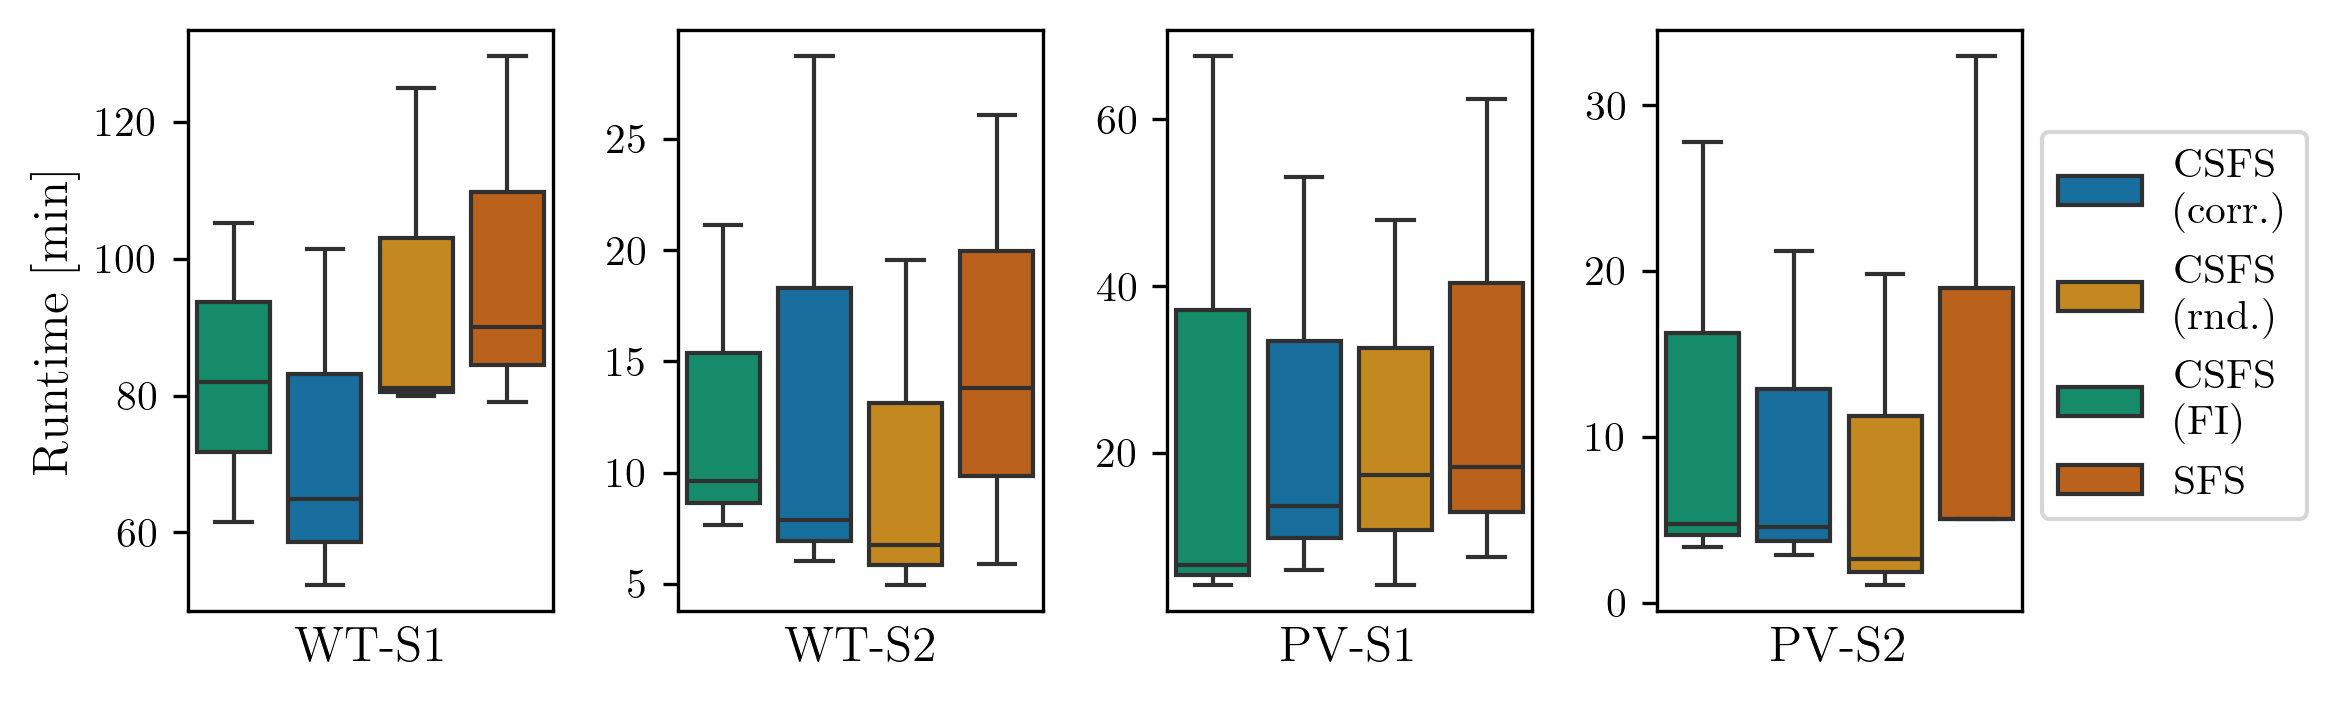

In [16]:
n_features = 2
curr_results = all_results_df.loc[~all_results_df["feature_selection.direction"].isna() & (all_results_df["feature_selection.n_features"] == n_features), :]
_dfs = {}
with plt.style.context("src/mplstyles/lncs.mplstyle"):
    fig, ax = plt.subplots(ncols=4, figsize=(7, 2.5))
    i = 0
    for ds_plot in ["WT-S1", "WT-S2", "PV-S1", "PV-S2"]:
        plot_df = curr_results.query(f"(`ds_plot` == '{ds_plot}')")
        _dfs[ds_plot] = plot_df
        sns.boxplot(
            plot_df,
            x="fs_method_plot",
            y=plot_df["fs_runtime"] / 60,
            palette="colorblind",
            hue="fs_method_plot",
            order=list(rename_fs_method.values())[:plot_df["fs_method_plot"].nunique()],
            log_scale=False,
            orient="v",
            ax=ax[i],
            legend=True,
        )
        ax[i].set_xticks([])
        ax[i].set_xlabel(ds_plot)
        if i == 0:
            ax[i].set_ylabel("Runtime [min]")
            ax[i].get_legend().remove()
            # ax[i].legend(bbox_to_anchor=(1.05, 1), ncols=2)
            fig.legend(ncols=1, bbox_to_anchor=(1.12, 0.82))
        else:
            ax[i].set_ylabel("")
            # hide legend
            ax[i].get_legend().remove()

        i += 1
    # plt.tight_layout()
    plt.savefig(Paths.REPORT / f"runtime_comparison_n={n_features}.pdf",
                bbox_inches="tight",
                pad_inches=0.05)
    plt.show()

In [17]:
ours = ["feature_importance"]
baseline = "singletons"
for ds_plot in ["WT-S1", "WT-S2", "PV-S1", "PV-S2"]:
    ours_df = all_results_df.query(
        f"(`ds_plot` == '{ds_plot}') & (`feature_selection.clustering.method` in {ours})"
    )
    baseline_df = all_results_df.query(
        f"(`ds_plot` == '{ds_plot}') & (`feature_selection.clustering.method` == '{baseline}')"
    )
    merged_df = ours_df.merge(baseline_df, how="right", on=["model.name", "feature_selection.n_features"], suffixes=("_ours", "_baseline"))
    diff = (
        100
        * (merged_df.loc[:, "fs_runtime_baseline"] - merged_df.loc[:, "fs_runtime_ours"])
        / merged_df.loc[:, "fs_runtime_baseline"]
    )
    # median_imp = np.median(diff)
    # ci_low, ci_high = np.percentile(diff, [2.5, 97.5])

    print(median_and_ci_to_latex(diff, p=0.95, precision=1))

$21.6\%\, (\text{95\% CI}: -4.6\!-\!35.7\%)$
$-7.4\%\, (\text{95\% CI}: -156.4\!-\!31.4\%)$
$44.4\%\, (\text{95\% CI}: -8.0\!-\!65.6\%)$
$19.0\%\, (\text{95\% CI}: 3.6\!-\!34.5\%)$


In [18]:
ours = ["feature_importance", "correlation", "random"]
baseline = "singletons"
ours_df = all_results_df.query(f"(`feature_selection.clustering.method` in {ours})")
baseline_df = all_results_df.query(f"(`feature_selection.clustering.method` == '{baseline}')")
merged_df = ours_df.merge(
    baseline_df, how="left", on=["model.name", "feature_selection.n_features", "ds_plot"], suffixes=("_ours", "_baseline")
)
diff = (
    (merged_df.loc[:, "fs_runtime_baseline"] - merged_df.loc[:, "fs_runtime_ours"])
    / merged_df.loc[:, "fs_runtime_baseline"]
)
# median_imp = np.median(diff)
# ci_low, ci_high = np.percentile(diff, [2.5, 97.5])
print(f"Average runtime improvement of all CSFS variants over SFS: {diff.mean():.2%}")

Average runtime improvement of all CSFS variants over SFS: 20.77%


# 7. Early Removal of Clusters

In [19]:
curr_results = all_results_df.query(
    "`feature_selection.clustering.method` in ['correlation', 'feature_importance', 'random']"
)
early_removal_percentage = curr_results["fast_stops"].sum() / curr_results["total_iterations"].sum()
print(f"Early removal percentage: {early_removal_percentage:.2%}")

Early removal percentage: 29.54%
